# Step 1: Load Final DistilBERT Model

In [2]:
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

In [3]:
tokenizer = AutoTokenizer.from_pretrained(
    "../models/distilbert_final"
)

In [4]:
model = AutoModelForSequenceClassification.from_pretrained(
    "../models/distilbert_final"
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [5]:
print(type(model))

<class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'>


In [6]:
print(model.config.num_labels)

2


In [7]:
print(model.config.id2label)

print(model.config.label2id)

{0: 'LABEL_0', 1: 'LABEL_1'}
{'LABEL_0': 0, 'LABEL_1': 1}


### Step 1 Summary

The final DistilBERT model and tokenizer were loaded successfully from the saved model directory. The model is configured for binary sentiment classification with two output classes:

- Class 0 → Negative Review
- Class 1 → Positive Review

This confirms that the trained model is ready for inference and error analysis.

# Step 2: Generate Predictions

In [8]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/imdb_preprocessed.csv"
)

In [9]:
print(df.shape)

df.head()

(49582, 7)


,review,sentiment,clean_review,tokens,tokens_no_stopwords,tokens_lemmatized,final_text
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"['one', 'of', 'the', 'other', 'reviewers', 'ha...","['one', 'reviewers', 'mentioned', 'watching', ...","['one', 'reviewer', 'mention', 'watch', 'oz', ...",one reviewer mention watch oz episode you ll h...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,"['a', 'wonderful', 'little', 'production', 'th...","['wonderful', 'little', 'production', 'filming...","['wonderful', 'little', 'production', 'filming...",wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"['i', 'thought', 'this', 'was', 'a', 'wonderfu...","['thought', 'wonderful', 'way', 'spend', 'time...","['think', 'wonderful', 'way', 'spend', 'time',...",think wonderful way spend time hot summer week...
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"['basically', 'theres', 'a', 'family', 'where'...","['basically', 'theres', 'family', 'little', 'b...","['basically', 'there', 's', 'family', 'little'...",basically there s family little boy jake think...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,"['petter', 'matteis', 'love', 'in', 'the', 'ti...","['petter', 'matteis', 'love', 'time', 'money',...","['petter', 'matteis', 'love', 'time', 'money',...",petter matteis love time money visually stunni...


In [10]:
df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

In [11]:
print(df["label"].value_counts())

label
1    24884
0    24698
Name: count, dtype: int64


In [12]:
df["label"]

0        1
1        1
2        1
3        0
4        1
        ..
49577    1
49578    0
49579    0
49580    0
49581    0
Name: label, Length: 49582, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_review"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

In [14]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(39665,)
(9917,)
(39665,)
(9917,)


In [15]:
print(X_test.iloc[0])

print()

print("Actual Label:", y_test.iloc[0])

my wife and i watched this after dvring it off of encore action this past week it has to be the worst horror flick either of us had ever seen predictable dialogue  my wife and i were guessing the lines before they were spoken hokey special effects a screenplay that drifted all over the place i think the part that was the most annoying was the stereotyping of the various characters in the plot not to mention the gratuitous sex scene between two of the young heroines in the movie neither of which had any real purpose other than to bare certain parts of their anatomy for the cameras this movie should be categorized as comedy not horror as the villains of the movie spiders were stop motion animated and not believable in the least i cant say that i would have done a better job making a film myself but it was very amateurish and wasnt even a b movie somewhere closer to a d movie or f if that is possible i think even science fiction  would have to pass on this one

Actual Label: 0


In [16]:
def predict_sentiment(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    with torch.no_grad():

        outputs = model(**inputs)

    prediction = torch.argmax(
        outputs.logits,
        dim=1
    ).item()

    return prediction

In [17]:
review = X_test.iloc[0]

prediction = predict_sentiment(review)

print("Prediction:", prediction)

print("Actual:", y_test.iloc[0])

Prediction: 0
Actual: 0


In [18]:
from tqdm import tqdm

y_pred = []

for review in tqdm(X_test):

    pred = predict_sentiment(review)

    y_pred.append(pred)

100%|██████████| 9917/9917 [11:51<00:00, 13.94it/s]


In [19]:
print(len(y_pred))

print(y_pred[:10])

9917
[0, 1, 1, 0, 0, 1, 0, 0, 1, 0]


In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9145911061813048


# Step 3: Create Prediction DataFrame

In [21]:
prediction_df = pd.DataFrame({
    "review": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred
})

prediction_df.head()

,review,actual,predicted
0,my wife and i watched this after dvring it off...,0,0
1,i was surprised how much i enjoyed this sure i...,1,1
2,such a delightful movie very heart warming one...,1,1
3,la lupa mannara aka werewolf woman of is a fi...,0,0
4,first this movie was not that badit was entert...,0,0


In [22]:
print(prediction_df.shape)

(9917, 3)


In [23]:
prediction_df.columns

Index(['review', 'actual', 'predicted'], dtype='str')

# Step 4: Find Wrong Predictions

In [24]:
wrong_predictions = prediction_df[
    prediction_df["actual"] != prediction_df["predicted"]
]

wrong_predictions.head()

,review,actual,predicted
24,despite being a huge fan of fred astaire and g...,0,1
27,im both amused and disgusted by the people who...,0,1
35,well wellroeg touched a bit of a nerve there d...,1,0
43,ok let me again admit that i havent seen any o...,0,1
45,im not here to tell you armored is kubrickian ...,1,0


In [25]:
print("Total Wrong Predictions:")
print(len(wrong_predictions))

Total Wrong Predictions:
847


In [26]:
error_rate = (
    len(wrong_predictions)
    / len(prediction_df)
) * 100

print(f"Error Rate: {error_rate:.2f}%")

Error Rate: 8.54%


In [27]:
wrong_predictions.sample(10)

,review,actual,predicted
1431,when i first saw this on tape about years aft...,1,0
2078,its like hard to like describe just how like e...,0,1
8596,im totally agree with garryjohal from singapor...,1,0
7753,i bought this cheap from the rental remnant at...,1,0
3023,actually this is a lie shrek d was actually th...,0,1
6633,alfred hitchcocks more assured telling of a fi...,1,0
2417,having seen the short a number of times at hor...,1,0
8432,when we are young we all pick out an ideal occ...,1,0
7408,forget easy rider head is the film about the ...,1,0
7115,i love this show i watched every episode last ...,0,1


In [54]:
print(df["sentiment"].value_counts())

sentiment
positive    24884
negative    24698
Name: count, dtype: int64


# Step 5: Analyze False Positives

In [28]:
false_positives = prediction_df[
    (prediction_df["actual"] == 0)
    &
    (prediction_df["predicted"] == 1)
]

false_positives.head()

,review,actual,predicted
24,despite being a huge fan of fred astaire and g...,0,1
27,im both amused and disgusted by the people who...,0,1
43,ok let me again admit that i havent seen any o...,0,1
162,black vengeance is an alternate title for ying...,0,1
164,this is among one of many usa attempts of rema...,0,1


In [29]:
print("Total False Positives:")
print(len(false_positives))

Total False Positives:
394


In [30]:
false_positives.sample(10)

,review,actual,predicted
6946,one would expect a movie with a famous comedia...,0,1
1038,after reading the book i loved the story watch...,0,1
2491,flashdance meets meatballs iii or maybe it sho...,0,1
8088,thats right you heard me i am a huge fan of ja...,0,1
2238,so far i disliked every single jean rollin mov...,0,1
4555,the figure of empress elizabeth of austria is...,0,1
6838,sure i like short cartoons but i didnt like th...,0,1
3729,i have to agree with most everyones opinion th...,0,1
2775,like im sure other people have said this guy i...,0,1
7916,the van is a feelgood movie about a guy who tr...,0,1


In [31]:
false_positives["review"].iloc[0]

'despite being a huge fan of fred astaire and ginger rogers movies it wasnt until about  years ago that i first saw follow the fleet i knew all the songs from an old astairerogers record yes vinyl but knew nothing of the plotunfortunately while the songs are catchy and ginger rogers character is sweet and funny you just cant like bake baker while trying to make up to his longtime partner he continually sabotages her career his character doesnt have the usual humour and elan of the other films astaire charactersworth watching for the songs and a great solo tap routine by ginger rogers'

# Step 6: Analyze False Negatives

In [32]:
false_negatives = prediction_df[
    (prediction_df["actual"] == 1)
    &
    (prediction_df["predicted"] == 0)
]

false_negatives.head()

,review,actual,predicted
35,well wellroeg touched a bit of a nerve there d...,1,0
45,im not here to tell you armored is kubrickian ...,1,0
51,this movie probably had a budget and still ma...,1,0
112,financially strapped paramount pulled out all ...,1,0
115,this documentary on dinosaurs was undoubtedly ...,1,0


In [33]:
print("Total False Negatives:")
print(len(false_negatives))

Total False Negatives:
453


In [34]:
false_negatives.sample(10)

,review,actual,predicted
427,a lot of people dont think branaghs hamlet fil...,1,0
3224,as other reviewers have noted this is an unjus...,1,0
7617,following the business coup of the year of ma...,1,0
2150,yes i did as i sit here redfaced remembering h...,1,0
6972,this pm entertainment production is laced with...,1,0
686,before this little blackandwhiter the touchy t...,1,0
6279,trick or treat quickie review this zany romp o...,1,0
8057,beautiful to watch but what would be the first...,1,0
1831,hot millions is a wellwritten wellacted tale a...,1,0
2058,i loved this program and for years searched fo...,1,0


In [35]:
false_negatives["review"].iloc[0]

'well wellroeg touched a bit of a nerve there didnt he he was a genius while he was cataloguing his various characters descents into psychosis for a couple of decades but as soon as he has the bad taste to suggest that redemption or even some good advice might be found in the bad old catholic church the hipperthanthou alternative movie crowd gets extra vicious worse still theresa russells character  faced with experiences that nothing in her avowedly rationalist outlook has an explanation for is unwillingly forced to deal with those experiences on another level  that of the spiritual you know the realm of the ignorant and superstitious the sort of thing that the arthouse cinephiles are supposed to be above oh the horror so she finds her marriage  the idea that it might be a uniquely important commitment  affirmed by what seems uncomfortably like divine intervention people who find this idea prima facie offensive could maybe ask themselves why they instinctively jump into attack mode at

# Next Step 7: Create Confusion Matrix Visualization

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[4546  394]
 [ 453 4524]]


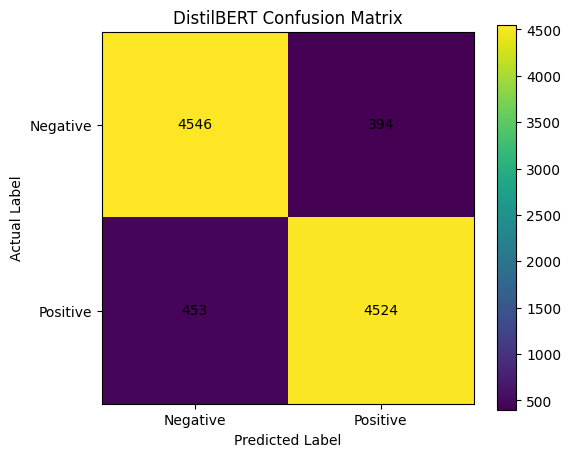

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0,1], ["Negative","Positive"])
plt.yticks([0,1], ["Negative","Positive"])

plt.title("DistilBERT Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center"
        )

plt.show()

# Step 8: Compare TF-IDF vs DistilBERT

In [38]:
comparison_df = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "DistilBERT"
    ],
    "Accuracy": [
        0.8921,
        0.9146
    ]
})

comparison_df

,Model,Accuracy
0,TF-IDF + Logistic Regression,0.8921
1,DistilBERT,0.9146


In [39]:
improvement = (
    (0.9146 - 0.8921)
    * 100
)

print(
    f"Accuracy Improvement: {improvement:.2f}%"
)

Accuracy Improvement: 2.25%


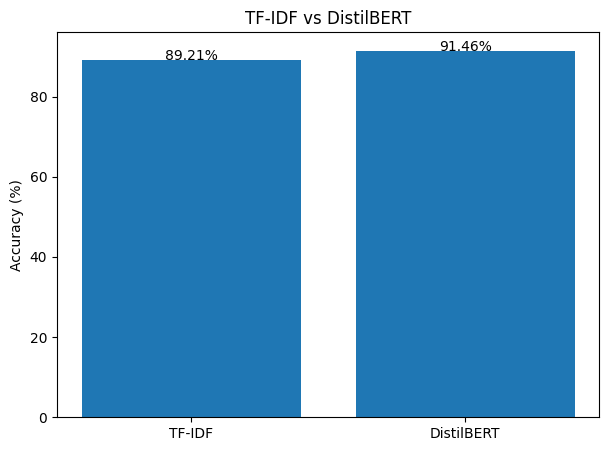

In [40]:
import matplotlib.pyplot as plt

models = [
    "TF-IDF",
    "DistilBERT"
]

accuracies = [
    89.21,
    91.46
]

plt.figure(figsize=(7,5))

plt.bar(
    models,
    accuracies
)

plt.ylabel("Accuracy (%)")
plt.title("TF-IDF vs DistilBERT")

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

# Step 9: Final Conclusions & Project Summary

# Final Project Findings

1. The IMDB dataset contained 49,582 movie reviews with nearly balanced positive and negative classes.

2. Text preprocessing successfully cleaned and normalized the reviews for machine learning and deep learning models.

3. TF-IDF with Logistic Regression achieved approximately 89.21% accuracy.

4. DistilBERT achieved 91.46% accuracy, outperforming the TF-IDF baseline by 2.25%.

5. DistilBERT demonstrated better contextual understanding and semantic representation of reviews.

6. Error analysis revealed that most misclassifications occurred in reviews containing mixed sentiments, sarcasm, or complex language.

# Key Observations

- DistilBERT outperformed traditional machine learning methods.
- Transformer models understand context better than bag-of-words approaches.
- Balanced datasets improve classification performance.
- Most errors occurred in ambiguous reviews.
- False Positives and False Negatives were relatively balanced.

# Business Impact

This system can be used to:

- Analyze customer feedback.
- Monitor product reviews.
- Track brand reputation.
- Analyze social media sentiment.
- Support decision-making using customer opinions.

# Project Limitations

- Sarcasm is difficult to detect.
- Mixed sentiment reviews may confuse the model.
- Long reviews may contain contradictory opinions.
- The model was trained only on English reviews.
- Domain-specific reviews may require additional fine-tuning.

# Future Improvements

- Use larger transformer models such as BERT or RoBERTa.
- Perform hyperparameter optimization.
- Add explainable AI techniques such as SHAP.
- Deploy the model using Streamlit or FastAPI.
- Build a real-time sentiment analysis dashboard.

# Final Conclusion

In this project, a complete Sentiment Analysis pipeline was developed using the IMDB Movie Reviews dataset.

The project included data exploration, preprocessing, TF-IDF baseline modeling, DistilBERT fine-tuning, model evaluation, and detailed error analysis.

The DistilBERT model achieved 91.46% accuracy and outperformed the TF-IDF baseline model by 2.25%.

The results demonstrate that transformer-based models provide superior contextual understanding and are highly effective for sentiment classification tasks.

This project successfully showcases both traditional machine learning and modern NLP techniques in an end-to-end workflow.